# Explicit RNN for a discrete SE(2) group

This notebook is the SE(2)-style analogue of the cyclic-group construction.  The group is

$$G = C_n^2 \rtimes C_m,$$

with the default choice $m=3$.  Elements are indexed as

$$g = (x,y,r), \qquad x,y \in C_n, \quad r \in C_m,$$

and flattened by

$$\mathrm{idx}(x,y,r) = r n^2 + x n + y.$$

The notebook is organized as:

1. group geometry and plotting helpers,
2. irreps of $C_n^2 \rtimes C_3$,
3. allocentric and egocentric encodings,
4. the exact finite-group RNN construction,
5. rollout and trajectory plotting,
6. hidden-neuron tuning curves.

In [25]:
# ============================================================
# 0. Imports and global style
# ============================================================

import math
import warnings
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import colors as mcolors
from hexalattice.hexalattice import create_hex_grid

np.set_printoptions(precision=3, suppress=True)

## 1. Group setup and triangular-lattice geometry

For $m=3$, the rotation action is the order-three triangular-lattice action

$$A = \begin{pmatrix}-1 & -1 \\ 1 & 0\end{pmatrix} \pmod n.$$

The group law is

$$((x_1,y_1),r_1)((x_2,y_2),r_2)
= ((x_1,y_1) + A^{r_1}(x_2,y_2), r_1+r_2).$$

In [2]:
# ============================================================
# 1. Discrete SE(2): C_n^2 ⋊ C_m, with default m=3
# ============================================================

_STANDARD_ACTIONS = {
    1: np.array([[1, 0], [0, 1]], dtype=int),
    2: np.array([[-1, 0], [0, -1]], dtype=int),
    3: np.array([[-1, -1], [1, 0]], dtype=int),
    4: np.array([[0, -1], [1, 0]], dtype=int),
    6: np.array([[0, -1], [1, 1]], dtype=int),
}


class DiscreteSE2Group:
    """
    Finite semidirect product C_n^2 ⋊ C_m.

    Elements are encoded as
        idx = r * n^2 + x * n + y.
    """

    def __init__(self, n, m=3):
        if n < 2:
            raise ValueError("n must be >= 2")
        if m not in _STANDARD_ACTIONS:
            raise ValueError("m must be one of {1, 2, 3, 4, 6}")

        self.n = int(n)
        self.m = int(m)
        self.order = self.m * self.n * self.n
        self.A = _STANDARD_ACTIONS[self.m] % self.n
        self.rot_mats = self._precompute_rotations()
        self.A_dual = self._compute_dual_action_matrix()

        actual_order = self._matrix_order()
        if actual_order is None:
            raise ValueError(f"A^m != I mod n={n}; group action is not well-defined.")
        if actual_order != self.m:
            warnings.warn(
                f"A has actual order {actual_order} mod n={n}; action is not faithful.",
                stacklevel=2,
            )

        self._compose_table = None
        self._inverse_table = None

    def encode(self, x, y, r):
        return (int(r) % self.m) * self.n * self.n + (int(x) % self.n) * self.n + (int(y) % self.n)

    def decode(self, idx):
        r, rem = divmod(int(idx), self.n * self.n)
        x, y = divmod(rem, self.n)
        return x, y, r

    def elements(self):
        return np.arange(self.order)

    def _precompute_rotations(self):
        mats = [np.eye(2, dtype=int) % self.n]
        for _ in range(1, self.m):
            mats.append((mats[-1] @ self.A) % self.n)
        return mats

    def _matrix_order(self):
        I = np.eye(2, dtype=int) % self.n
        Ak = I.copy()
        for k in range(1, self.m + 1):
            Ak = (Ak @ self.A) % self.n
            if np.array_equal(Ak, I):
                return k
        return None

    def _compute_dual_action_matrix(self):
        """
        Dual action on translation characters: (A^{-1})^T mod n.
        """
        a, b = int(self.A[0, 0]), int(self.A[0, 1])
        c, d = int(self.A[1, 0]), int(self.A[1, 1])
        det = (a * d - b * c) % self.n
        if math.gcd(det, self.n) != 1:
            raise ValueError(f"A is not invertible mod n={self.n}")
        det_inv = pow(det, -1, self.n)
        A_inv = (det_inv * np.array([[d, -b], [-c, a]], dtype=int)) % self.n
        return A_inv.T % self.n

    def apply_rotation(self, r, x, y):
        A_r = self.rot_mats[int(r) % self.m]
        xy = A_r @ np.array([x, y], dtype=int)
        return int(xy[0] % self.n), int(xy[1] % self.n)

    def compose(self, g, h):
        x1, y1, r1 = self.decode(g)
        x2, y2, r2 = self.decode(h)
        x2r, y2r = self.apply_rotation(r1, x2, y2)
        return self.encode(x1 + x2r, y1 + y2r, r1 + r2)

    def compose_table(self):
        if self._compose_table is None:
            table = np.empty((self.order, self.order), dtype=int)
            for g in range(self.order):
                for h in range(self.order):
                    table[g, h] = self.compose(g, h)
            self._compose_table = table
        return self._compose_table

    def identity(self):
        return self.encode(0, 0, 0)

    def inverse(self, g):
        e = self.identity()
        for h in range(self.order):
            if self.compose(g, h) == e and self.compose(h, g) == e:
                return h
        raise RuntimeError("inverse not found")

    def inverse_table(self):
        if self._inverse_table is None:
            self._inverse_table = np.array([self.inverse(g) for g in range(self.order)], dtype=int)
        return self._inverse_table

    def left_action(self, g, x):
        """
        Left action on a code x over the group:
            (g · x)[h] = x[g^{-1} h].
        """
        inv_g = self.inverse_table()[g]
        table = self.compose_table()
        return x[table[inv_g, :]]

    def cumulative_product(self, seq):
        """
        Effective product induced by the recurrence.

        With the left-action and Fourier conventions used here, the update with
        drives g_1, ..., g_T decodes the state
            g_T ... g_1 · x_allo.
        """
        total = self.identity()
        for g in seq:
            total = self.compose(int(g), total)
        return total


In [75]:
# ============================================================
# 1.1 Triangular-lattice plotting helpers
# ============================================================

from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection


def triangular_coords(n, mode="rhombus"):
    """
    Display coordinates for the triangular lattice.

    mode="rhombus":
        Honest triangular basis:
            e1 = (1, 0), e2 = (1/2, sqrt(3)/2).

    mode="offset":
        Wrapped/offset-row display:
            even rows aligned, odd rows shifted by 1/2.
        This makes the periodic n x n arena look more square.
    """
    x = np.arange(n)
    y = np.arange(n)
    X_idx, Y_idx = np.meshgrid(x, y, indexing="ij")

    X = X_idx + 0.5 * Y_idx
    Y = (np.sqrt(3) / 2) * Y_idx

    if mode == "rhombus":
        return X, Y

    if mode == "offset":
        cutoff = n - 0.5
        X = X.copy()
        X[X > cutoff] -= n
        return X, Y

    raise ValueError("mode must be 'offset' or 'rhombus'.")


def group_signal_to_tensor(group, signal):
    """
    Convert a flat signal over G to tensor shape (m, n, n), indexed by r,x,y.
    """
    return np.asarray(signal).reshape(group.m, group.n, group.n)


def tensor_to_group_signal(tensor):
    """
    Convert tensor shape (m,n,n) to flat group signal.
    """
    return np.asarray(tensor).reshape(-1)


# ------------------------------------------------------------
# Direction alignment helpers
# ------------------------------------------------------------

def rotated_indices_for_direction(group, r):
    """
    For direction r, compute the rotated lattice indices

        (x_rot, y_rot) = A^r (x, y) mod n.

    Returns X_rot, Y_rot arrays of shape (n,n).
    """
    n = group.n

    x = np.arange(n)
    y = np.arange(n)
    X_idx, Y_idx = np.meshgrid(x, y, indexing="ij")

    # Robust to either naming convention.
    if hasattr(group, "rot_mats"):
        A_r = group.rot_mats[r % group.m]
    elif hasattr(group, "_rot_mats"):
        A_r = group._rot_mats[r % group.m]
    else:
        raise AttributeError("group must have either `rot_mats` or `_rot_mats`.")

    X_rot = (A_r[0, 0] * X_idx + A_r[0, 1] * Y_idx) % n
    Y_rot = (A_r[1, 0] * X_idx + A_r[1, 1] * Y_idx) % n

    return X_rot, Y_rot


def align_direction_slice_to_allocentric(group, values_xy, r):
    """
    Rotate one direction slice into a common allocentric frame.

    values_xy is indexed by local/heading-dependent coordinates (x,y).
    This returns a new array indexed by allocentric coordinates A^r(x,y).
    """
    values_xy = np.asarray(values_xy)

    X_rot, Y_rot = rotated_indices_for_direction(group, r)

    aligned = np.zeros_like(values_xy)

    for x in range(group.n):
        for y in range(group.n):
            xr = X_rot[x, y]
            yr = Y_rot[x, y]
            aligned[xr, yr] = values_xy[x, y]

    return aligned


def align_tensor_directions_to_allocentric(group, tensor):
    """
    Align every direction slice tensor[r] into the same allocentric frame.

    Input shape:
        tensor[r, x, y]

    Output shape:
        aligned_tensor[r, x_alloc, y_alloc]
    """
    tensor = np.asarray(tensor)
    aligned = np.zeros_like(tensor)

    for r in range(group.m):
        aligned[r] = align_direction_slice_to_allocentric(
            group,
            tensor[r],
            r,
        )

    return aligned


def reduce_directions_in_allocentric_frame(group, tensor, reduce="sum"):
    """
    Combine direction slices after rotating each slice into the allocentric frame.

    reduce='sum':
        sum over aligned directions.

    reduce='mean':
        average over aligned directions.
    """
    aligned = align_tensor_directions_to_allocentric(group, tensor)

    if reduce == "sum":
        return aligned.sum(axis=0)

    if reduce == "mean":
        return aligned.mean(axis=0)

    raise ValueError("reduce must be 'sum' or 'mean'.")


# ------------------------------------------------------------
# Hexagonal heatmap plotting helpers
# ------------------------------------------------------------

from matplotlib import colors as mcolors
from hexalattice.hexalattice import create_hex_grid
from hexalattice.hexalattice import plot_single_lattice_custom_colors

def plot_lattice_scalar(
    group,
    values_xy,
    title=None,
    ax=None,
    cmap="viridis",
    vmin=None,
    vmax=None,
    show_colorbar=True,
    plotting_gap=0.02,
    edge_color=(1, 1, 1, 1),
    line_width=0.7,
    rotate_deg=0,
    mode="offset"
):
    """
    Plot values_xy[x,y] on the triangular lattice as a hexagonal heatmap.

    Uses our triangular lattice coordinates as the hex centers, then asks
    hexalattice to draw/color the hexagons. This avoids any indexing mismatch
    from create_hex_grid's internal ordering.
    """
    values = np.asarray(values_xy)
    X, Y = triangular_coords(group.n, mode=mode)

    if ax is None:
        fig, ax = plt.subplots(figsize=(4.8, 4.2), constrained_layout=True)
    else:
        fig = ax.figure

    if vmin is None:
        vmin = values.min()
    if vmax is None:
        vmax = values.max()
    if vmax <= vmin:
        vmax = vmin + 1e-12

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap_obj = plt.get_cmap(cmap)

    flat_vals = values.reshape(-1)
    face_colors = cmap_obj(norm(flat_vals))

    plot_single_lattice_custom_colors(
        X.reshape(-1),
        Y.reshape(-1),
        face_color=face_colors,
        edge_color=np.tile(edge_color, (flat_vals.size, 1)),
        min_diam=1.0,
        plotting_gap=plotting_gap,
        rotate_deg=rotate_deg,
        line_width=line_width,
        h_ax=ax,
    )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    if title is not None:
        ax.set_title(title)

    if show_colorbar:
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_obj)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)

    return ax


def plot_group_signal_by_direction(
    group,
    signal,
    title=None,
    reduce=None,
    cmap="viridis",
    align_directions=True,
    common_color_scale=True,
):
    """
    Plot signal over translations, either separately by direction r
    or reduced over directions.

    Parameters
    ----------
    reduce : None, 'mean', or 'sum'
        None: show one panel per direction.
        'mean'/'sum': align direction slices and then aggregate.

    align_directions : bool
        If True, each r slice is rotated into the common allocentric frame
        before plotting or combining.

        This is the natural option when r=0,1,2 represent different headings.

    common_color_scale : bool
        If True, use a shared color scale across direction panels.
    """
    tensor = group_signal_to_tensor(group, signal)

    if align_directions:
        tensor_to_plot = align_tensor_directions_to_allocentric(group, tensor)
        alignment_label = "aligned"
    else:
        tensor_to_plot = tensor
        alignment_label = "raw"

    # --------------------------------------------------------
    # Reduced plot over directions
    # --------------------------------------------------------
    if reduce in ["mean", "sum"]:
        if align_directions:
            values_xy = reduce_directions_in_allocentric_frame(
                group,
                tensor,
                reduce=reduce,
            )
        else:
            if reduce == "mean":
                values_xy = tensor.mean(axis=0)
            else:
                values_xy = tensor.sum(axis=0)

        fig, ax = plt.subplots(figsize=(4.8, 4.2), constrained_layout=True)

        if title is None:
            panel_title = rf"{reduce} over directions ({alignment_label})"
        else:
            panel_title = rf"{title}: {reduce} over directions ({alignment_label})"

        plot_lattice_scalar(
            group,
            values_xy,
            title=panel_title,
            ax=ax,
            cmap=cmap,
        )

        plt.show()
        return

    if reduce is not None:
        raise ValueError("reduce must be None, 'mean', or 'sum'.")

    # --------------------------------------------------------
    # One panel per direction
    # --------------------------------------------------------
    if common_color_scale:
        vmin = np.min(tensor_to_plot)
        vmax = np.max(tensor_to_plot)
    else:
        vmin = None
        vmax = None

    fig, axes = plt.subplots(
        1,
        group.m,
        figsize=(4.3 * group.m, 4.0),
        constrained_layout=True,
    )

    if group.m == 1:
        axes = [axes]

    for r, ax in enumerate(axes):
        if title is None:
            panel_title = rf"$r={r}$ ({alignment_label})"
        else:
            panel_title = rf"{title}, $r={r}$ ({alignment_label})"

        plot_lattice_scalar(
            group,
            tensor_to_plot[r],
            title=panel_title,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            show_colorbar=True,
        )

    plt.show()

## 2. Irreps of $C_n^2 times C_3$

The irreps are built from orbits of translation characters under the dual action $(A^{-1})^T$.  For an orbit of size $t$, the stabilizer has size $h=m/t$, and each stabilizer character gives an irrep of dimension $t$.

In [76]:
# ============================================================
# 2. Irreps for C_n^2 ⋊ C_m
# ============================================================

@dataclass
class Irrep:
    name: str
    mats: np.ndarray       # shape: |G| x dim x dim
    orbit: tuple
    stabilizer_char: int

    @property
    def dim(self):
        return self.mats.shape[1]


def dual_action_once(group, j1, j2):
    Ad = group.A_dual
    n = group.n
    return (
        int((Ad[0, 0] * j1 + Ad[0, 1] * j2) % n),
        int((Ad[1, 0] * j1 + Ad[1, 1] * j2) % n),
    )


def compute_char_orbits(group):
    """
    Partition character labels (j1,j2) into C_m-orbits under the dual action.
    """
    visited = set()
    orbits_by_size = {}

    for j1 in range(group.n):
        for j2 in range(group.n):
            if (j1, j2) in visited:
                continue

            orbit = []
            a, b = j1, j2

            for _ in range(group.m):
                if (a, b) in orbit:
                    break
                orbit.append((a, b))
                a, b = dual_action_once(group, a, b)

            for pt in orbit:
                visited.add(pt)

            orbits_by_size.setdefault(len(orbit), []).append(orbit)

    return orbits_by_size


def build_irreps(group):
    """
    Build irreps by the orbit/stabilizer construction.
    """
    n, m = group.n, group.m
    order = group.order
    omega = np.exp(2j * np.pi / n)

    orbit_dict = compute_char_orbits(group)
    irreps = []

    for orbit_size in sorted(orbit_dict):
        for orb_idx, orbit in enumerate(orbit_dict[orbit_size]):
            h = m // orbit_size
            dim = orbit_size

            for s in range(h):
                mats = np.zeros((order, dim, dim), dtype=np.complex128)

                for idx in range(order):
                    x, y, r = group.decode(idx)

                    for j in range(dim):
                        total = r + j
                        i = total % dim
                        q = total // dim

                        a_i, b_i = orbit[i]
                        char_val = omega ** (a_i * x + b_i * y)
                        stab_phase = np.exp(2j * np.pi * s * q / h)
                        mats[idx, i, j] = char_val * stab_phase

                name = f"orbit{orb_idx:02d}_size{orbit_size}_s{s}_dim{dim}"
                irreps.append(Irrep(name=name, mats=mats, orbit=tuple(orbit), stabilizer_char=s))

    return irreps


def summarize_irreps(group, irreps):
    dims = np.array([rho.dim for rho in irreps])
    print("Irrep summary")
    print("-------------")
    print("|G|:", group.order)
    print("number of irreps:", len(irreps))
    print("dimensions:", {int(d): int(np.sum(dims == d)) for d in sorted(set(dims))})
    print("sum dim^2:", int(np.sum(dims ** 2)))
    print()
    for i, rho in enumerate(irreps[:12]):
        print(f"{i:2d}: {rho.name:24s} dim={rho.dim}, orbit={rho.orbit}, s={rho.stabilizer_char}")
    if len(irreps) > 12:
        print(f"... {len(irreps) - 12} more")

## 3. Encodings

The allocentric code is a Gaussian bump on the triangular lattice, repeated across all three directions.  The egocentric code is a random real signal over the full group, resampled until every irrep Fourier matrix is invertible.

In [115]:
# ============================================================
# 3. Encodings and finite-group Fourier transform
# ============================================================

def finite_group_fourier_hat(signal, rho):
    """
    Fourier matrix at irrep rho:
        xhat[rho] = sum_g rho(g)^† x[g].
    """
    signal = np.asarray(signal)
    mats = rho.mats
    return np.einsum("gab,g->ab", np.conjugate(np.swapaxes(mats, 1, 2)), signal)


def min_fourier_singular_value(signal, irreps):
    mins = []
    for rho in irreps:
        xhat = finite_group_fourier_hat(signal, rho)
        mins.append(np.linalg.svd(xhat, compute_uv=False).min())
    return float(np.min(mins))


def make_random_group_encoding(group, irreps, seed=0, min_sval=1e-5, max_tries=10_000):
    """
    Make a real encoding over G whose Fourier matrix is invertible at every irrep.
    """
    rng = np.random.default_rng(seed)

    for _ in range(max_tries):
        x = rng.normal(size=group.order)
        x = x + 0.5 * rng.normal(size=group.order) ** 2
        if min_fourier_singular_value(x, irreps) > min_sval:
            return x

    raise RuntimeError("failed to sample an encoding with invertible Fourier matrices")


def triangular_periodic_distance_sq(group, x, y, center):
    """
    Squared distance on a periodic triangular lattice.

    We search over nearby periodic copies of the center and take the shortest
    Euclidean distance in the triangular basis.
    """
    n = group.n
    cx, cy = center

    best = np.inf
    for ax in [-1, 0, 1]:
        for ay in [-1, 0, 1]:
            dx = x - (cx + ax * n)
            dy = y - (cy + ay * n)

            # triangular basis metric: |dx e1 + dy e2|^2
            dist2 = dx * dx + dx * dy + dy * dy
            best = min(best, dist2)

    return best


def gaussian_bump_triangular_all_directions(group, center=(2, 2), sigma=1.2, amplitude=1.0, baseline=0.0):
    """
    Gaussian bump on C_n^2, copied across all directions r=0,...,m-1.
    """
    tensor = np.zeros((group.m, group.n, group.n), dtype=float)

    for r in range(group.m):
        for x in range(group.n):
            for y in range(group.n):
                dist2 = triangular_periodic_distance_sq(group, x, y, center)
                tensor[r, x, y] = baseline + amplitude * np.exp(-0.5 * dist2 / sigma**2)

    return tensor_to_group_signal(tensor)


def decoded_argmax(group, signal, reduce_over_directions=True):
    """
    Decode bump center from a group signal.

    If reduce_over_directions=True, sum over r and return the best (x,y), together
    with the direction marginal. Otherwise return full argmax (x,y,r).
    """
    tensor = group_signal_to_tensor(group, signal)

    if reduce_over_directions:
        spatial = tensor.sum(axis=0)
        x, y = np.unravel_index(np.argmax(spatial), spatial.shape)
        r_marginal = tensor[:, x, y]
        return int(x), int(y), r_marginal

    idx = int(np.argmax(signal))
    return group.decode(idx)

Irrep summary
-------------
|G|: 7500
number of irreps: 836
dimensions: {1: 3, 3: 833}
sum dim^2: 7500

 0: orbit00_size1_s0_dim1    dim=1, orbit=((0, 0),), s=0
 1: orbit00_size1_s1_dim1    dim=1, orbit=((0, 0),), s=1
 2: orbit00_size1_s2_dim1    dim=1, orbit=((0, 0),), s=2
 3: orbit00_size3_s0_dim3    dim=3, orbit=((0, 1), (49, 49), (1, 0)), s=0
 4: orbit01_size3_s0_dim3    dim=3, orbit=((0, 2), (48, 48), (2, 0)), s=0
 5: orbit02_size3_s0_dim3    dim=3, orbit=((0, 3), (47, 47), (3, 0)), s=0
 6: orbit03_size3_s0_dim3    dim=3, orbit=((0, 4), (46, 46), (4, 0)), s=0
 7: orbit04_size3_s0_dim3    dim=3, orbit=((0, 5), (45, 45), (5, 0)), s=0
 8: orbit05_size3_s0_dim3    dim=3, orbit=((0, 6), (44, 44), (6, 0)), s=0
 9: orbit06_size3_s0_dim3    dim=3, orbit=((0, 7), (43, 43), (7, 0)), s=0
10: orbit07_size3_s0_dim3    dim=3, orbit=((0, 8), (42, 42), (8, 0)), s=0
11: orbit08_size3_s0_dim3    dim=3, orbit=((0, 9), (41, 41), (9, 0)), s=0
... 824 more
min singular value over Fourier matrices of x_

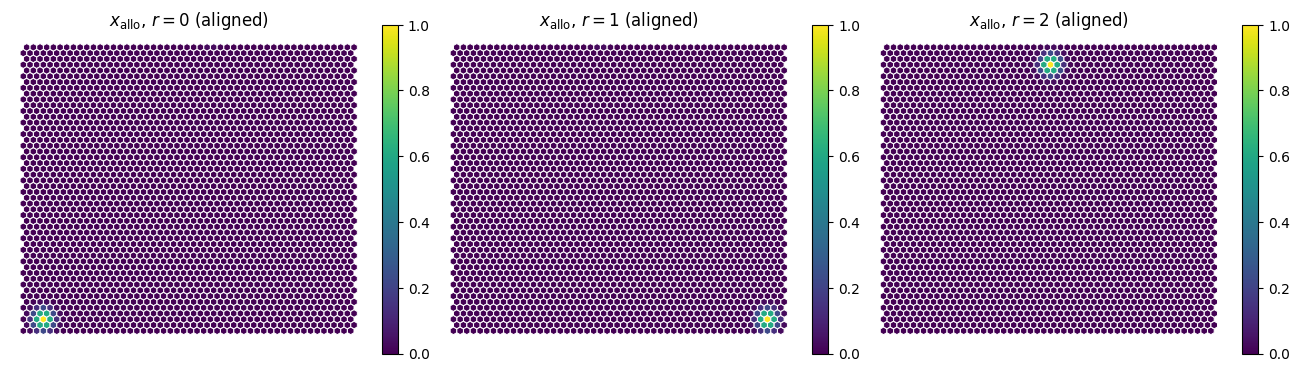

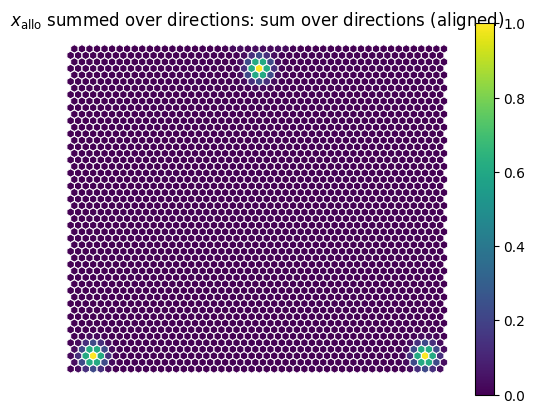

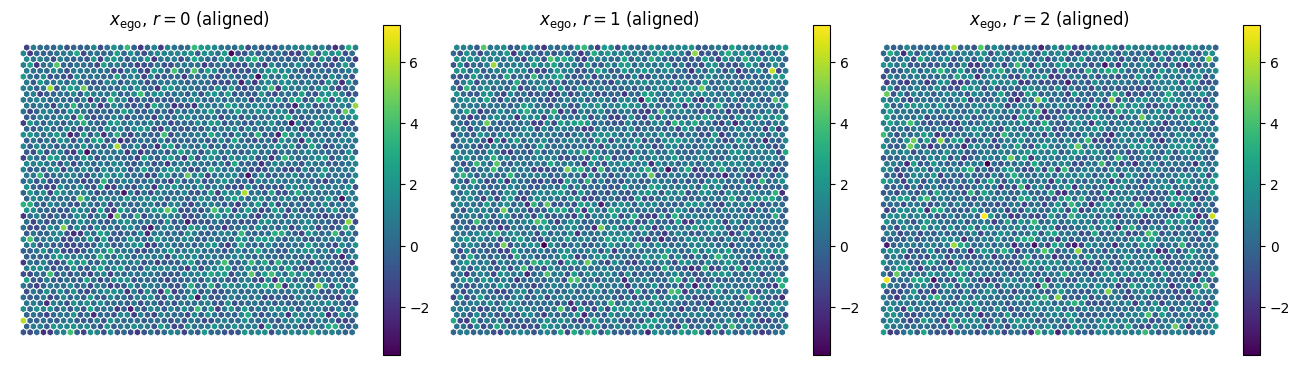

In [145]:
# ============================================================
# 3.1 Choose group and encodings
# ============================================================

# Keep this small at first.  n=4 keeps the construction fast; increase n after the notebook runs end-to-end.
n = 50
m = 3
q_rho = 3
num_irreps = 10 # This is the number of irreps to use in RNN solution

G = DiscreteSE2Group(n=n, m=m)
irreps = build_irreps(G)
summarize_irreps(G, irreps)

# Allocentric code: Gaussian bump over translations, copied across directions.
center_xy = (2, 2)
sigma = 1.0
x_allo = gaussian_bump_triangular_all_directions(
    G,
    center=center_xy,
    sigma=sigma,
    amplitude=1.0,
    baseline=0.0,
)

# Egocentric code: generic invertible code over the full group.
x_ego = make_random_group_encoding(G, irreps, seed=10, min_sval=1e-5)

print("min singular value over Fourier matrices of x_ego:", min_fourier_singular_value(x_ego, irreps))

plot_group_signal_by_direction(G, x_allo, title=r"$x_{\mathrm{allo}}$", reduce=None, align_directions=True)
plot_group_signal_by_direction(G, x_allo, title=r"$x_{\mathrm{allo}}$ summed over directions", reduce="sum", align_directions=True)
plot_group_signal_by_direction(G, x_ego, title=r"$x_{\mathrm{ego}}$", reduce=None, align_directions=True)

## 4. Exact finite-group RNN construction

For each irrep $ho$, each sign pair, each phase $\delta$, and each triple $(k_0,k_1,k_2)$, we build one hidden neuron.  This is the direct finite-group version of the cyclic construction.

In [146]:
# ============================================================
# 4. Approximate / exact RNN construction for a general finite group
#    Optionally keep only the top irreps by Fourier power of x_allo.
# ============================================================

def squared_relu(z):
    return np.maximum(0, z) ** 2


def amplitude_factors(n_rho, q_rho, group_order, mode="balanced"):
    """
    Choose A_u, A_v, A_w satisfying
        A_u A_v A_w = n_rho / (q_rho |G|).
    """
    product = n_rho / (q_rho * group_order)

    if mode == "balanced":
        A = product ** (1 / 3)
        return A, A, A

    if mode == "put_on_Av":
        return 1.0, product, 1.0

    raise ValueError("mode must be 'balanced' or 'put_on_Av'.")


def matrix_unit(dim, i, j):
    E = np.zeros((dim, dim), dtype=np.complex128)
    E[i, j] = 1.0
    return E


def trace_features_from_s(rho, s):
    """
    Return real vector g -> Re Tr(rho(g) s).
    """
    return np.real(np.einsum("gab,ba->g", rho.mats, s))


def finite_group_fourier_power(x, rho, normalize_by_dim=True):
    """
    Fourier power of x at irrep rho.

    If normalize_by_dim=True, use ||xhat[rho]||_F^2 / dim(rho).
    """
    xhat = finite_group_fourier_hat(x, rho)
    power = np.linalg.norm(xhat, ord="fro") ** 2

    if normalize_by_dim:
        power = power / rho.dim

    return power


def select_irreps_by_x_allo_power(
    irreps,
    x_allo,
    num_irreps=None,
    normalize_by_dim=True,
    always_include_trivial=True,
):
    """
    Select the top irreps by Fourier power of x_allo.

    Returns
    -------
    selected_irreps : list
        Irreps to use in the RNN construction.

    selected_indices : list[int]
        Original/global indices of the selected irreps.
    """
    if num_irreps is None or num_irreps >= len(irreps):
        return list(irreps), list(range(len(irreps)))

    scores = []
    for rho_idx, rho in enumerate(irreps):
        score = finite_group_fourier_power(
            x_allo,
            rho,
            normalize_by_dim=normalize_by_dim,
        )
        scores.append((score, rho_idx))

    scores = sorted(scores, reverse=True)

    selected_indices = []

    # Usually irreps[0] is the trivial irrep. Including it preserves the DC mode.
    if always_include_trivial:
        selected_indices.append(0)

    for score, rho_idx in scores:
        if rho_idx not in selected_indices:
            selected_indices.append(rho_idx)
        if len(selected_indices) >= num_irreps:
            break

    selected_indices = sorted(selected_indices)
    selected_irreps = [irreps[i] for i in selected_indices]

    return selected_irreps, selected_indices


def build_finite_group_rnn_params(
    group,
    irreps,
    x_ego,
    x_allo=None,
    q_rho=3,
    amplitude_mode="balanced",
    num_irreps=None,
    irrep_selection="all",
    normalize_power_by_dim=True,
    always_include_trivial=True,
):
    """
    Build W_in, W_drive, W_out, W_mix for the finite-group construction.

    By default, irrep_selection='all', so this is the exact construction.

    To build a cheaper approximate construction, use

        irrep_selection='x_allo_power'
        num_irreps=K

    which keeps only the K irreps with largest Fourier power in x_allo.
    """
    if irrep_selection == "all" or num_irreps is None:
        selected_irreps = list(irreps)
        selected_indices = list(range(len(irreps)))

    elif irrep_selection == "first":
        selected_indices = list(range(min(num_irreps, len(irreps))))
        selected_irreps = [irreps[i] for i in selected_indices]

    elif irrep_selection == "x_allo_power":
        if x_allo is None:
            raise ValueError("x_allo must be provided when irrep_selection='x_allo_power'.")

        selected_irreps, selected_indices = select_irreps_by_x_allo_power(
            irreps=irreps,
            x_allo=x_allo,
            num_irreps=num_irreps,
            normalize_by_dim=normalize_power_by_dim,
            always_include_trivial=always_include_trivial,
        )

    else:
        raise ValueError("irrep_selection must be 'all', 'first', or 'x_allo_power'.")

    eps_pairs = [(+1, +1), (-1, +1), (-1, -1), (+1, -1)]

    rows_u = []
    rows_v = []
    cols_w = []
    meta = []

    for local_rho_idx, rho in enumerate(selected_irreps):
        rho_idx = selected_indices[local_rho_idx]
        d = rho.dim

        xhat = finite_group_fourier_hat(x_ego, rho)
        min_sval = np.linalg.svd(xhat, compute_uv=False).min()

        if min_sval < 1e-10:
            raise ValueError(
                f"x_ego Fourier matrix nearly singular for {rho.name}; "
                f"min sval={min_sval}"
            )

        xhat_inv_dagger = np.linalg.inv(xhat.conj().T)

        A_u, A_v, A_w = amplitude_factors(
            n_rho=d,
            q_rho=q_rho,
            group_order=group.order,
            mode=amplitude_mode,
        )

        for eps1, eps2 in eps_pairs:
            for delta in range(q_rho):
                phase_u = np.exp(1j * np.pi * delta / q_rho)
                phase_v = np.exp(1j * np.pi * delta / q_rho)
                phase_w = np.exp(2j * np.pi * delta / q_rho)

                for k0 in range(d):
                    for k1 in range(d):
                        for k2 in range(d):
                            E_k0k2 = matrix_unit(d, k0, k2)
                            E_k2k1 = matrix_unit(d, k2, k1)
                            E_k0k1 = matrix_unit(d, k0, k1)

                            s_u = eps1 * A_u * phase_u * E_k0k2
                            s_v = eps1 * eps2 * A_v * phase_v * (xhat_inv_dagger @ E_k2k1)
                            s_w = eps2 * A_w * phase_w * E_k0k1

                            u = trace_features_from_s(rho, s_u)
                            v = trace_features_from_s(rho, s_v)
                            w = trace_features_from_s(rho, s_w)

                            rows_u.append(u)
                            rows_v.append(v)
                            cols_w.append(w)

                            meta.append({
                                "rho_idx": rho_idx,
                                "local_rho_idx": local_rho_idx,
                                "rho_name": rho.name,
                                "rho_dim": d,
                                "eps1": eps1,
                                "eps2": eps2,
                                "delta": delta,
                                "k0": k0,
                                "k1": k1,
                                "k2": k2,
                            })

    W_in = np.array(rows_u)
    W_drive = np.array(rows_v)
    W_out = np.array(cols_w).T
    W_mix = W_in @ W_out

    return {
        "group": group,
        "irreps": selected_irreps,
        "all_irreps": irreps,
        "selected_rho_indices": selected_indices,
        "q_rho": q_rho,
        "x_ego": x_ego,
        "W_in": W_in,
        "W_drive": W_drive,
        "W_out": W_out,
        "W_mix": W_mix,
        "meta": meta,
        "amplitude_mode": amplitude_mode,
        "irrep_selection": irrep_selection,
        "num_irreps": num_irreps,
    }


def rnn_forward_sequence(params, x_allo, seq):
    group = params["group"]
    W_in = params["W_in"]
    W_drive = params["W_drive"]
    W_out = params["W_out"]
    W_mix = params["W_mix"]
    x_ego = params["x_ego"]

    h = squared_relu(W_in @ x_allo + W_drive @ group.left_action(seq[0], x_ego))

    for gt in seq[1:]:
        h = squared_relu(W_mix @ h + W_drive @ group.left_action(gt, x_ego))

    y = W_out @ h
    return y, h


def rnn_rollout(params, x_allo, seq):
    group = params["group"]
    W_in = params["W_in"]
    W_drive = params["W_drive"]
    W_out = params["W_out"]
    W_mix = params["W_mix"]
    x_ego = params["x_ego"]

    cumulative_states = []
    true_outputs = []
    pred_outputs = []
    hidden_states = []

    cumulative = group.identity()
    h = None

    for t, gt in enumerate(seq):
        cumulative = group.compose(int(gt), cumulative)

        if t == 0:
            h = squared_relu(W_in @ x_allo + W_drive @ group.left_action(gt, x_ego))
        else:
            h = squared_relu(W_mix @ h + W_drive @ group.left_action(gt, x_ego))

        y = W_out @ h

        cumulative_states.append(cumulative)
        true_outputs.append(group.left_action(cumulative, x_allo))
        pred_outputs.append(y)
        hidden_states.append(h.copy())

    return {
        "cumulative_states": np.array(cumulative_states),
        "true_outputs": np.array(true_outputs),
        "pred_outputs": np.array(pred_outputs),
        "hidden_states": np.array(hidden_states),
    }

In [147]:
# ============================================================
# 4.1 Build and test the exact RNN
# ============================================================

params = build_finite_group_rnn_params(
    group=G,
    irreps=irreps,
    x_ego=x_ego,
    x_allo=x_allo,
    q_rho=3,
    amplitude_mode="balanced",
    num_irreps=num_irreps,
    irrep_selection="x_allo_power",
)

W_in = params["W_in"]
W_drive = params["W_drive"]
W_out = params["W_out"]
W_mix = params["W_mix"]

print("Shapes")
print("------")
print("W_in:    ", W_in.shape)
print("W_drive: ", W_drive.shape)
print("W_out:   ", W_out.shape)
print("W_mix:   ", W_mix.shape)
print("hidden width H:", W_in.shape[0])

Shapes
------
W_in:     (2928, 7500)
W_drive:  (2928, 7500)
W_out:    (7500, 2928)
W_mix:    (2928, 2928)
hidden width H: 2928


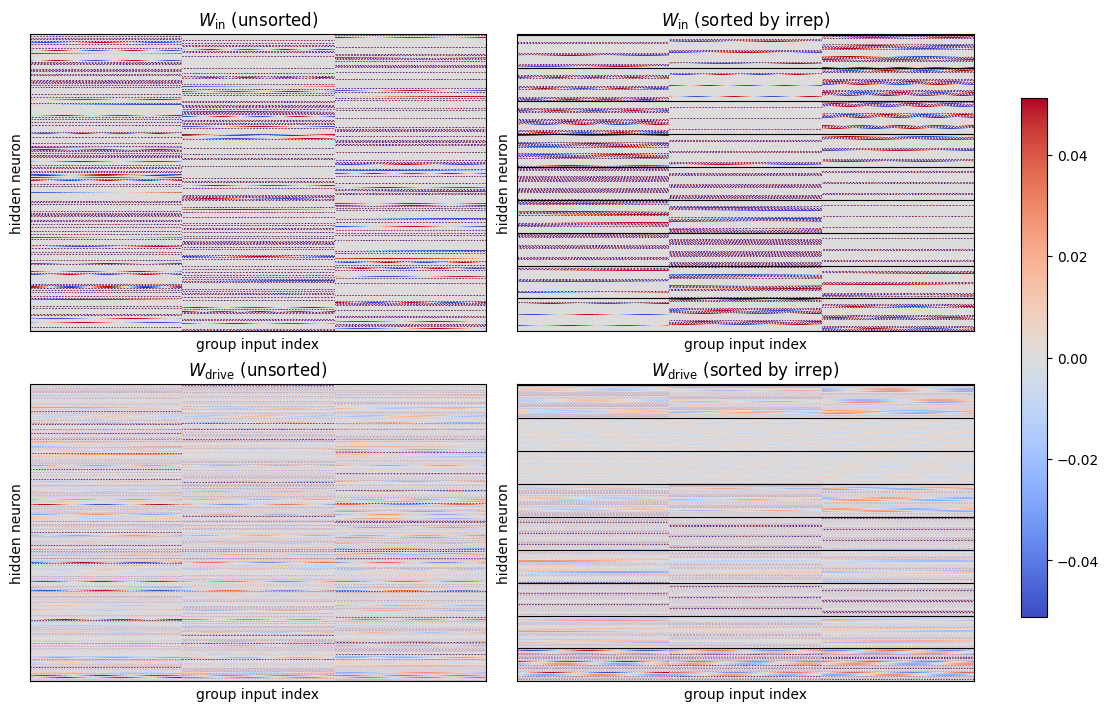

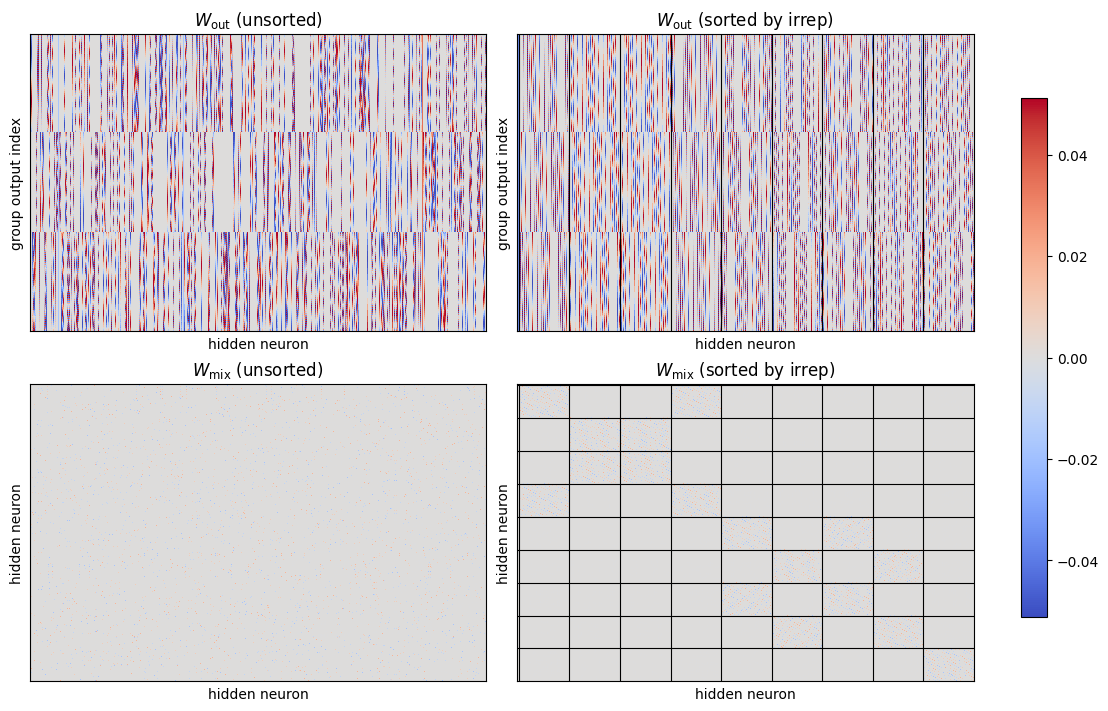

Weight summary
--------------
Group order |G|: 7500
Hidden width H: 2928
Number of irreps: 10

Irrep blocks
------------
rho_idx=  0 | dim= 1 | size=   12 | rows     0:   12
rho_idx=  3 | dim= 3 | size=  324 | rows    12:  336
rho_idx=  4 | dim= 3 | size=  324 | rows   336:  660
rho_idx= 50 | dim= 3 | size=  324 | rows   660:  984
rho_idx= 51 | dim= 3 | size=  324 | rows   984: 1308
rho_idx= 52 | dim= 3 | size=  324 | rows  1308: 1632
rho_idx= 98 | dim= 3 | size=  324 | rows  1632: 1956
rho_idx= 99 | dim= 3 | size=  324 | rows  1956: 2280
rho_idx=144 | dim= 3 | size=  324 | rows  2280: 2604
rho_idx=145 | dim= 3 | size=  324 | rows  2604: 2928


In [148]:
# ============================================================
# Visualizing the weights of the discrete SE(2) construction
# ============================================================

def plot_weight_matrix(
    ax,
    M,
    title="",
    vlim=None,
    row_boundaries=None,
    col_boundaries=None,
    xlabel="",
    ylabel="",
):
    """
    Plot a weight matrix with optional row/column block boundaries.
    """
    if vlim is None:
        vlim = np.max(np.abs(M))
        if vlim == 0:
            vlim = 1.0

    im = ax.imshow(
        M,
        cmap="coolwarm",
        vmin=-vlim,
        vmax=vlim,
        interpolation="nearest",
        aspect="auto",
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_yticks([])

    if row_boundaries is not None:
        for b in row_boundaries:
            ax.axhline(b - 0.5, color="black", linewidth=0.8)

    if col_boundaries is not None:
        for b in col_boundaries:
            ax.axvline(b - 0.5, color="black", linewidth=0.8)

    return im


def get_irrep_sorted_permutation_and_boundaries(meta):
    """
    Sort hidden neurons by irrep index and return the corresponding
    permutation and block boundaries.

    Assumes each meta entry is a dict containing at least:
        "rho_idx", "rho_dim"
    """
    rho_labels = np.array([mi["rho_idx"] for mi in meta])
    rho_dims = np.array([mi["rho_dim"] for mi in meta])

    # Stable sort keeps the internal construction order within each irrep block.
    perm_sorted = np.argsort(rho_labels, kind="stable")

    sorted_rhos = rho_labels[perm_sorted]
    sorted_dims = rho_dims[perm_sorted]

    boundaries = []
    block_info = []

    start = 0
    unique_rhos = []

    while start < len(sorted_rhos):
        rho_idx = sorted_rhos[start]
        end = start

        while end < len(sorted_rhos) and sorted_rhos[end] == rho_idx:
            end += 1

        unique_rhos.append(rho_idx)

        block_info.append({
            "rho_idx": int(rho_idx),
            "rho_dim": int(sorted_dims[start]),
            "start": int(start),
            "end": int(end),
            "size": int(end - start),
        })

        if end < len(sorted_rhos):
            boundaries.append(end)

        start = end

    return perm_sorted, np.array(boundaries), block_info


# ------------------------------------------------------------
# Pull out weights and metadata
# ------------------------------------------------------------

W_in = params["W_in"]
W_drive = params["W_drive"]
W_out = params["W_out"]
W_mix = params["W_mix"]
meta = params["meta"]

H = W_in.shape[0]
group_order = W_in.shape[1]

perm_sorted, boundaries, block_info = get_irrep_sorted_permutation_and_boundaries(meta)

# Random permutation for the "unsorted" view
rng = np.random.default_rng(0)
perm_random = rng.permutation(H)

# ------------------------------------------------------------
# Reordered matrices
# ------------------------------------------------------------

W_in_unsorted = W_in[perm_random, :]
W_in_sorted = W_in[perm_sorted, :]

W_drive_unsorted = W_drive[perm_random, :]
W_drive_sorted = W_drive[perm_sorted, :]

W_out_unsorted = W_out[:, perm_random]
W_out_sorted = W_out[:, perm_sorted]

W_mix_unsorted = W_mix[np.ix_(perm_random, perm_random)]
W_mix_sorted = W_mix[np.ix_(perm_sorted, perm_sorted)]

# Shared color limits
vlim_in = np.max(np.abs(W_in))
vlim_drive = np.max(np.abs(W_drive))
vlim_out = np.max(np.abs(W_out))
vlim_mix = np.max(np.abs(W_mix))


# ------------------------------------------------------------
# Plot W_in and W_drive
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

im = plot_weight_matrix(
    axes[0, 0],
    W_in_unsorted,
    title=r"$W_{\mathrm{in}}$ (unsorted)",
    vlim=vlim_in,
    xlabel="group input index",
    ylabel="hidden neuron",
)

plot_weight_matrix(
    axes[0, 1],
    W_in_sorted,
    title=r"$W_{\mathrm{in}}$ (sorted by irrep)",
    vlim=vlim_in,
    row_boundaries=boundaries,
    xlabel="group input index",
    ylabel="hidden neuron",
)

plot_weight_matrix(
    axes[1, 0],
    W_drive_unsorted,
    title=r"$W_{\mathrm{drive}}$ (unsorted)",
    vlim=vlim_drive,
    xlabel="group input index",
    ylabel="hidden neuron",
)

plot_weight_matrix(
    axes[1, 1],
    W_drive_sorted,
    title=r"$W_{\mathrm{drive}}$ (sorted by irrep)",
    vlim=vlim_drive,
    row_boundaries=boundaries,
    xlabel="group input index",
    ylabel="hidden neuron",
)

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


# ------------------------------------------------------------
# Plot W_out and W_mix
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)

im = plot_weight_matrix(
    axes[0, 0],
    W_out_unsorted,
    title=r"$W_{\mathrm{out}}$ (unsorted)",
    vlim=vlim_out,
    xlabel="hidden neuron",
    ylabel="group output index",
)

plot_weight_matrix(
    axes[0, 1],
    W_out_sorted,
    title=r"$W_{\mathrm{out}}$ (sorted by irrep)",
    vlim=vlim_out,
    col_boundaries=boundaries,
    xlabel="hidden neuron",
    ylabel="group output index",
)

plot_weight_matrix(
    axes[1, 0],
    W_mix_unsorted,
    title=r"$W_{\mathrm{mix}}$ (unsorted)",
    vlim=vlim_mix,
    xlabel="hidden neuron",
    ylabel="hidden neuron",
)

plot_weight_matrix(
    axes[1, 1],
    W_mix_sorted,
    title=r"$W_{\mathrm{mix}}$ (sorted by irrep)",
    vlim=vlim_mix,
    row_boundaries=boundaries,
    col_boundaries=boundaries,
    xlabel="hidden neuron",
    ylabel="hidden neuron",
)

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


# ------------------------------------------------------------
# Print irrep block summary
# ------------------------------------------------------------

print("Weight summary")
print("--------------")
print("Group order |G|:", group_order)
print("Hidden width H:", H)
print("Number of irreps:", len(block_info))
print()

print("Irrep blocks")
print("------------")
for bi in block_info:
    print(
        f"rho_idx={bi['rho_idx']:3d} | "
        f"dim={bi['rho_dim']:2d} | "
        f"size={bi['size']:5d} | "
        f"rows {bi['start']:5d}:{bi['end']:5d}"
    )

## 5. Long-sequence rollout and trajectory plotting

For visualization, we use small local motions on the triangular lattice.  The decoded bump center is plotted on the triangular lattice, with wraparound handled by the group law.

In [167]:
# ============================================================
# 5. Rollout and trajectory on the triangular lattice
# ============================================================

track_color = "#E45756"

def make_momentum_motion_sequence(
    group,
    T=100,
    seed=0,
    include_rotations=False,
    momentum=True,
    p_turn=0.18,
    p_stay=0.04,
    start_xy=None,
    margin=2,
    max_resample=20,
):
    """
    Generate local motions as group elements without crossing display boundaries.

    The path is constrained to stay inside

        margin <= x <= n - 1 - margin
        margin <= y <= n - 1 - margin

    in lattice coordinates. This avoids wraparound jumps in the plotted trajectory.

    If start_xy is provided, the first group element moves the cumulative state
    to start_xy, so the trajectory begins near the center of the arena.
    """
    rng = np.random.default_rng(seed)
    n = group.n

    if start_xy is None:
        start_xy = (n // 2, n // 2)

    # Make sure the requested start is inside the allowed window.
    x = int(np.clip(start_xy[0], margin, n - 1 - margin))
    y = int(np.clip(start_xy[1], margin, n - 1 - margin))

    dirs_xy = np.array([
        [ 1,  0],
        [ 0,  1],
        [-1,  1],
        [-1,  0],
        [ 0, -1],
        [ 1, -1],
    ])

    def inside_bounds(x_new, y_new):
        return (
            margin <= x_new <= n - 1 - margin
            and margin <= y_new <= n - 1 - margin
        )

    seq = [group.encode(x, y, 0)]

    if not momentum:
        steps_xy = np.vstack([[[0, 0]], dirs_xy])

        for _ in range(T - 1):
            for _ in range(max_resample):
                dx, dy = steps_xy[rng.integers(0, len(steps_xy))]
                if inside_bounds(x + dx, y + dy):
                    break
            else:
                dx, dy = 0, 0

            x += dx
            y += dy

            r = rng.choice([0, 0, 0, 1, 2]) if include_rotations else 0
            seq.append(group.encode(dx, dy, r))

        return np.array(seq, dtype=int)

    dir_idx = rng.integers(0, 6)

    for _ in range(T - 1):
        if rng.random() < p_stay:
            dx, dy = 0, 0
        else:
            # Propose a momentum step, but redirect if it leaves the arena.
            accepted = False

            for _ in range(max_resample):
                proposed_dir = dir_idx

                if rng.random() < p_turn:
                    proposed_dir = (dir_idx + rng.choice([-1, 1])) % 6

                dx, dy = dirs_xy[proposed_dir]

                if inside_bounds(x + dx, y + dy):
                    dir_idx = proposed_dir
                    accepted = True
                    break

                # If blocked, turn away and try again.
                dir_idx = (dir_idx + rng.choice([-1, 1])) % 6

            if not accepted:
                dx, dy = 0, 0

        x += dx
        y += dy

        r = rng.choice([0, 0, 0, 1, 2]) if include_rotations else 0
        seq.append(group.encode(dx, dy, r))

    return np.array(seq, dtype=int)


def decode_centers_from_outputs(group, outputs):
    centers = []
    direction_marginals = []

    for y in outputs:
        cx, cy, rm = decoded_argmax(group, y, reduce_over_directions=True)
        centers.append((cx, cy))
        direction_marginals.append(rm)

    return np.array(centers), np.array(direction_marginals)


def true_centers_from_cumulative_states(group, center_xy, cumulative_states):
    true = []

    for g in cumulative_states:
        cx, cy, cr = group.decode(g)

        # Center transforms under left action by the cumulative group element.
        tx, ty = group.apply_rotation(cr, center_xy[0], center_xy[1])
        true.append(((cx + tx) % group.n, (cy + ty) % group.n))

    return np.array(true, dtype=int)


def center_errors_periodic_triangular(group, pred, true):
    """
    Return shortest triangular-lattice distance between predicted and true centers.
    """
    errs = []

    for (px, py), (tx, ty) in zip(pred, true):
        dist2 = triangular_periodic_distance_sq(group, px, py, (tx, ty))
        errs.append(np.sqrt(dist2))

    return np.array(errs)


def plot_lattice_trajectory(G, true_centers, pred_centers, title="Bump center trajectory", order="C", save_path=None):
    fig, ax = plt.subplots(figsize=(7.4, 5.4), constrained_layout=True)

    hex_centers, ax = create_hex_grid(
        nx=G.n, ny=G.n, do_plot=True, h_ax=ax,
        min_diam=1.0, plotting_gap=0.02,
        face_color=np.tile([[0.92, 0.92, 0.92, 1.0]], (G.n * G.n, 1)),
        edge_color=(1, 1, 1, 1), line_width=0.7,
    )

    xy = hex_centers.reshape(G.n, G.n, 2, order=order)
    true_xy = np.array([xy[x, y] for x, y in true_centers])
    pred_xy = np.array([xy[x, y] for x, y in pred_centers])

    ax.scatter(true_xy[:, 0], true_xy[:, 1], s=40, color=track_color, alpha=0.40,
               linewidths=0, label="true bump path", zorder=2)
    ax.plot(true_xy[:, 0], true_xy[:, 1], color=track_color, lw=2.4, alpha=0.95,
            label="true bump center", zorder=3)
    ax.plot(pred_xy[:, 0], pred_xy[:, 1], "k--", lw=2.0, alpha=0.95,
            label="predicted theory peak", zorder=4)

    ax.scatter(*true_xy[0], s=120, marker="o", color=track_color,
               edgecolors="black", linewidths=0.8, label="start", zorder=5)
    ax.scatter(*true_xy[-1], s=160, marker="*", color=track_color,
               edgecolors="black", linewidths=0.8, label="end", zorder=6)

    ax.set(aspect="equal", xticks=[], yticks=[], title=title)
    ax.set_frame_on(False)
    ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(0.94, 0.94))

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

Long-sequence tracking summary
------------------------------
max output error:         3.0687830247310575
mean output error:        3.068426223994825
max center error:         0.0
mean center error:        0.0


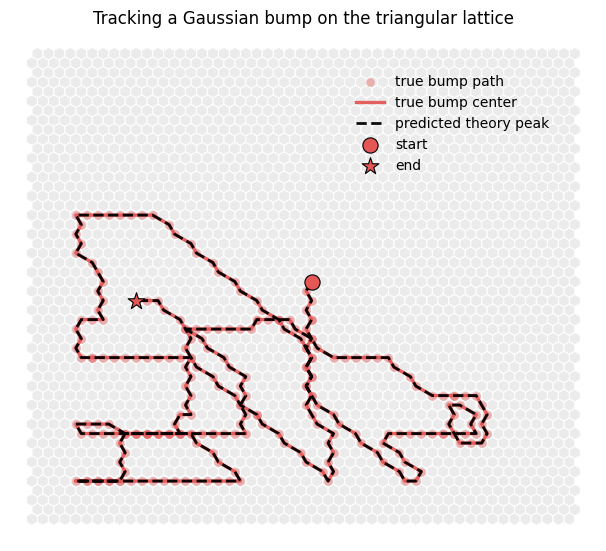

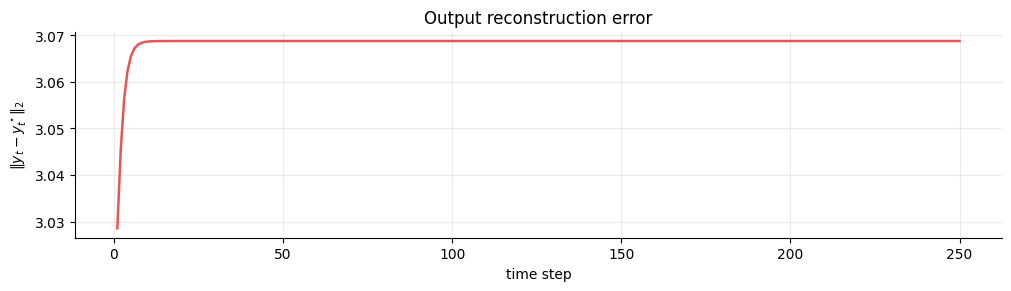

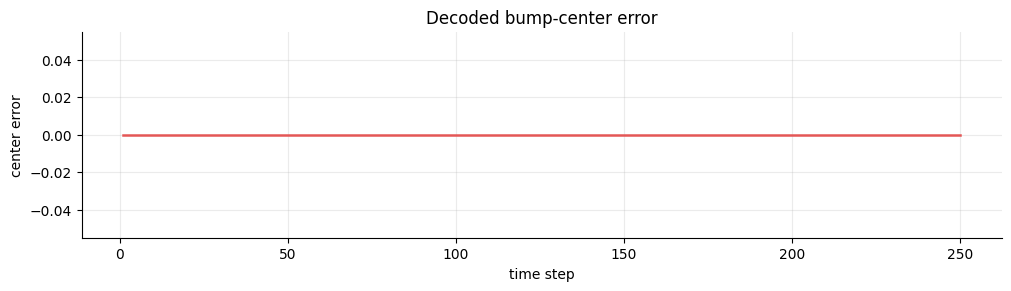

In [168]:
# ------------------------------------------------------------
# Run rollout
# ------------------------------------------------------------
T = 250

# Choose the first motion so that the bump center starts near the middle.
start_xy = (
    (G.n // 2 - center_xy[0]) % G.n,
    (G.n // 2 - center_xy[1]) % G.n,
)

seq = make_momentum_motion_sequence(
    G,
    T=T,
    seed=1,
    include_rotations=False,
    momentum=True,
    p_turn=0.18,
    p_stay=0.04,
    start_xy=start_xy,
)

rollout = rnn_rollout(params, x_allo, seq)

true_centers = true_centers_from_cumulative_states(
    G,
    center_xy,
    rollout["cumulative_states"],
)

pred_centers, pred_direction_marginals = decode_centers_from_outputs(
    G,
    rollout["pred_outputs"],
)

output_err = np.linalg.norm(
    rollout["pred_outputs"] - rollout["true_outputs"],
    axis=1,
)

center_err = center_errors_periodic_triangular(
    G,
    pred_centers,
    true_centers,
)

print("Long-sequence tracking summary")
print("------------------------------")
print("max output error:        ", output_err.max())
print("mean output error:       ", output_err.mean())
print("max center error:        ", center_err.max())
print("mean center error:       ", center_err.mean())

plot_lattice_trajectory(
    G,
    true_centers,
    pred_centers,
    title="Tracking a Gaussian bump on the triangular lattice",
    save_path="se2_triangular_lattice_tracking.pdf",
)

# ------------------------------------------------------------
# Error plots
# ------------------------------------------------------------
time = np.arange(1, T + 1)

fig, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
ax.plot(time, output_err, color=track_color, linewidth=1.8)
ax.set_xlabel("time step")
ax.set_ylabel(r"$\|y_t - y_t^\star\|_2$")
ax.set_title("Output reconstruction error")
ax.grid(True, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.savefig("se2_output_reconstruction_error.png", bbox_inches="tight", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
ax.plot(time, center_err, color=track_color, linewidth=1.8)
ax.set_xlabel("time step")
ax.set_ylabel("center error")
ax.set_title("Decoded bump-center error")
ax.grid(True, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.savefig("se2_center_error.png", bbox_inches="tight", dpi=300)
plt.show()

## 6. Tuning curves

For a hidden neuron $i$, we probe states

$$h(g)=\sigma(W_{\mathrm{in}}(g\cdot x_{\mathrm{allo}})+W_{\mathrm{drive}}x_{\mathrm{ego}}).$$

The tuning curve is the activation of neuron $i$ as a function of $g\in G$.  Since $G$ has both translation and direction coordinates, we can visualize tuning curves as heatmaps over the triangular lattice, either separately by direction or aggregated over direction.

In [174]:
# ============================================================
# 6. Hidden-neuron tuning curves
# ============================================================

def compute_probe_hidden_states(params, x_allo, drive_element=None):
    """
    Probe hidden states h(g) = sigma(W_in (g · x_allo) + W_drive (drive · x_ego)).
    """
    group = params["group"]
    W_in = params["W_in"]
    W_drive = params["W_drive"]
    x_ego = params["x_ego"]

    if drive_element is None:
        drive_element = group.identity()

    b_drive = W_drive @ group.left_action(drive_element, x_ego)

    H_probe = []
    for g in range(group.order):
        xg = group.left_action(g, x_allo)
        h_g = squared_relu(W_in @ xg + b_drive)
        H_probe.append(h_g)

    return np.array(H_probe)  # |G| x H


def select_representative_neurons(params, max_neurons=6, min_dim=None, skip_trivial=True):
    """
    Pick representative neurons from distinct irreps.
    """
    meta = params["meta"]
    selected = []
    seen_rhos = set()

    for i, mi in enumerate(meta):
        rho_idx = mi["rho_idx"]
        rho_dim = mi["rho_dim"]

        if rho_idx in seen_rhos:
            continue
        if min_dim is not None and rho_dim < min_dim:
            continue
        if skip_trivial and rho_dim == 1:
            continue

        selected.append(i)
        seen_rhos.add(rho_idx)

        if len(selected) >= max_neurons:
            break

    # Fallback: if filters are too strict, allow 1D irreps but still keep distinct rho_idx.
    if len(selected) < max_neurons and skip_trivial:
        for i, mi in enumerate(meta):
            rho_idx = mi["rho_idx"]

            if rho_idx in seen_rhos:
                continue
            if min_dim is not None and mi["rho_dim"] < min_dim:
                continue

            selected.append(i)
            seen_rhos.add(rho_idx)

            if len(selected) >= max_neurons:
                break

    return selected


def tuning_curve_to_lattice(group, tuning_curve, mode="sum", align_directions=True):
    """
    Convert one tuning curve over G into a single n x n lattice field.

    mode='sum': sum over directions.
    mode='mean': average over directions.
    """
    tensor = group_signal_to_tensor(group, tuning_curve)

    if align_directions:
        tensor = align_tensor_directions_to_allocentric(group, tensor)

    if mode == "sum":
        return tensor.sum(axis=0)

    if mode == "mean":
        return tensor.mean(axis=0)

    raise ValueError("mode must be 'sum' or 'mean'.")


def plot_selected_tuning_curves_row(
    params,
    H_probe,
    selected_indices,
    mode="sum",
    center=False,
    cmap="viridis",
    save_prefix="se2_tuning_curves_row",
    figsize_per_panel=3.2,
):
    """
    Plot selected raw tuning curves as one row of lattice heatmaps and save the figure.

    By default center=False, so these are raw hidden activations and should be nonnegative.
    """
    group = params["group"]
    meta = params["meta"]
    tuning_curves = H_probe.T

    fields = []
    titles = []

    for idx in selected_indices:
        tc = tuning_curves[idx]

        if center:
            tc = tc - tc.mean()

        field = tuning_curve_to_lattice(
            group,
            tc,
            mode=mode,
            align_directions=True,
        )

        mi = meta[idx]
        fields.append(field)
        titles.append(
            rf"$\rho={mi['rho_idx']}$, $d={mi['rho_dim']}$"
            "\n"
            rf"$\delta={mi['delta']},\ k=({mi['k0']},{mi['k1']},{mi['k2']})$"
        )

    num_sel = len(fields)

    vmin = min(np.min(f) for f in fields)
    vmax = max(np.max(f) for f in fields)

    fig, axes = plt.subplots(
        1,
        num_sel,
        figsize=(figsize_per_panel * num_sel, 3.2),
        constrained_layout=True,
    )

    if num_sel == 1:
        axes = [axes]

    for ax, field, title in zip(axes, fields, titles):
        plot_lattice_scalar(
            group,
            field,
            title=title,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            show_colorbar=False,
            line_width=0.0
        )

    sm = plt.cm.ScalarMappable(
        norm=plt.Normalize(vmin=vmin, vmax=vmax),
        cmap=plt.get_cmap(cmap),
    )
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=axes,
        fraction=0.025,
        pad=0.02,
    )

    fig.suptitle(
        rf"Representative hidden-neuron tuning curves ({mode} over directions)",
        fontsize=14,
        y=1.05,
    )

    fig.savefig(f"{save_prefix}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_prefix}.png", bbox_inches="tight", dpi=300)

    plt.show()

Selected neurons
----------------
12 {'rho_idx': 3, 'local_rho_idx': 1, 'rho_name': 'orbit00_size3_s0_dim3', 'rho_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
336 {'rho_idx': 4, 'local_rho_idx': 2, 'rho_name': 'orbit01_size3_s0_dim3', 'rho_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
660 {'rho_idx': 50, 'local_rho_idx': 3, 'rho_name': 'orbit47_size3_s0_dim3', 'rho_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
984 {'rho_idx': 51, 'local_rho_idx': 4, 'rho_name': 'orbit48_size3_s0_dim3', 'rho_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
1308 {'rho_idx': 52, 'local_rho_idx': 5, 'rho_name': 'orbit49_size3_s0_dim3', 'rho_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
1632 {'rho_idx': 98, 'local_rho_idx': 6, 'rho_name': 'orbit95_size3_s0_dim3', 'rho_dim': 3, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}


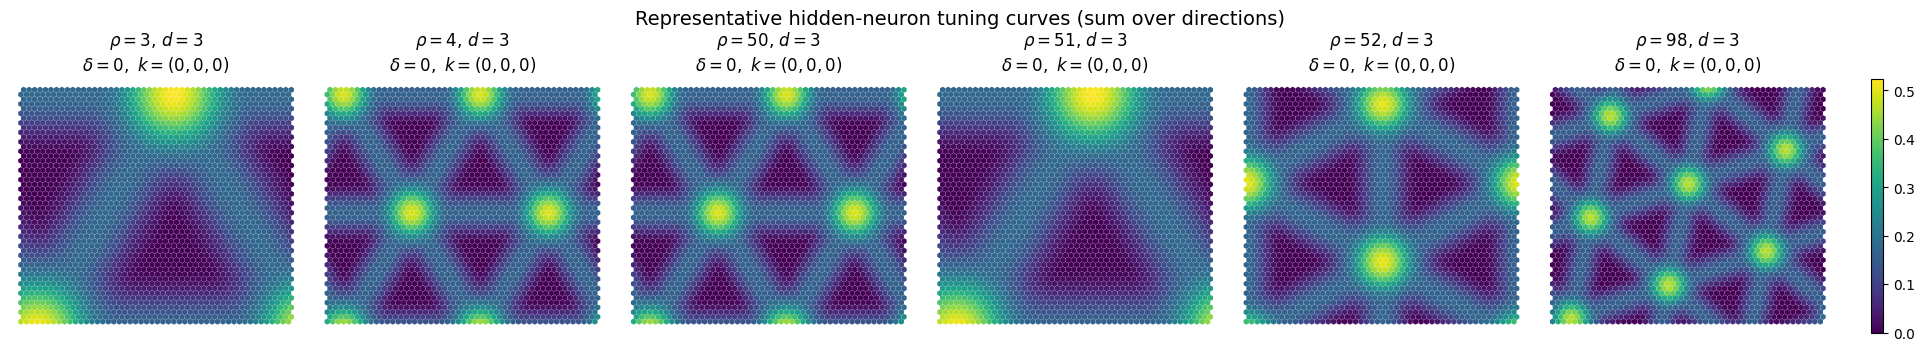

In [175]:
# ============================================================
# 6.1 Plot representative tuning curves
# ============================================================

H_probe = compute_probe_hidden_states(params, x_allo)

selected_indices = select_representative_neurons(
    params,
    max_neurons=6,
    min_dim=3,
)

print("Selected neurons")
print("----------------")
for idx in selected_indices:
    print(idx, params["meta"][idx])

plot_selected_tuning_curves_row(
    params,
    H_probe,
    selected_indices,
    mode="sum",
    center=False,
    cmap="viridis",
    save_prefix="se2_representative_tuning_curves_raw",
)

## Notes and suggested modifications

- Increase `n` only after the default notebook runs.  The hidden width scales like $4\sum_ho q_ho n_ho^3$, and `W_mix` is dense.
- For $m=3$, most nontrivial irreps are 3-dimensional, so the RNN gets much wider than in the cyclic case.
- The allocentric code is currently copied across all direction slices.  If you want a direction-selective allocentric code, modify `gaussian_bump_triangular_all_directions`.
- The trajectory cell defaults to pure translation moves.  Set `include_rotations=True` to test coupled rotation/translation motion.


1. Fix the plotting indexing issue for the hexagonal heatmap
2. Make it such the construction doesn't use all irreps as a means of preventing the width from being so large
3. ???? Start making final plots ????
